# Notebook 6 — State-wise validation for county-level wildfire risk modeling

This notebook performs a **stronger geographic validation** of the county-level wildfire expected annual loss model.

## Purpose
Earlier notebooks used a standard random train/test split. That is useful, but it can still place geographically similar counties in both training and test sets.

Here we evaluate whether the model still works when counties are split more strictly by **state groups**.

## What this notebook does
1. loads the county-level environmental modeling file,
2. removes rows with missing environmental predictors,
3. compares:
   - random split validation,
   - grouped cross-validation by state,
4. reports performance for:
   - baseline county variables only,
   - environmental variables only,
   - combined baseline + environmental variables,
5. saves a results table and grouped predictions.

## Input file
Upload:
- `nri_wildfire_county_model_env_conus.csv`

## Output files
This notebook will generate:
- `wildfire_risk_statewise_validation_results.csv`
- `wildfire_risk_statewise_group_predictions.csv`
- `wildfire_risk_statewise_combined_feature_importance.csv`
- thesis export PDFs/PNGs in `/content/thesis_exports/notebook6_statewise_validation_no_titles/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 150)

In [ ]:
# ============================================================
# Export helper functions for Notebook 6 thesis tables/figures
# No titles are added to exported tables or plots.
# ============================================================

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

EXPORT_DIR = Path("/content/thesis_exports/notebook6_statewise_validation_no_titles")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def save_dataframe_as_pdf(df, filename, rows_per_page=25, fontsize=8, fig_width=13):
    """
    Save a pandas DataFrame as a clean multi-page PDF table without a title.
    """
    path = EXPORT_DIR / filename
    df_to_save = df.copy()

    for col in df_to_save.columns:
        if pd.api.types.is_numeric_dtype(df_to_save[col]):
            df_to_save[col] = df_to_save[col].apply(
                lambda x: f"{x:,.4f}" if pd.notna(x) and abs(x) < 100000 else f"{x:,.0f}" if pd.notna(x) else ""
            )
        else:
            df_to_save[col] = df_to_save[col].astype(str)

    with PdfPages(path) as pdf:
        for start in range(0, len(df_to_save), rows_per_page):
            page_df = df_to_save.iloc[start:start + rows_per_page]

            fig_height = max(3.5, 0.40 * len(page_df) + 1.0)
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            ax.axis("off")

            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                cellLoc="center",
                loc="center"
            )

            table.auto_set_font_size(False)
            table.set_fontsize(fontsize)
            table.scale(1, 1.25)

            for key, cell in table.get_celld().items():
                cell.set_linewidth(0.4)
                if key[0] == 0:
                    cell.set_text_props(weight="bold")
                    cell.set_facecolor("#eeeeee")

            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved table PDF: {path}")
    return path

## 1. Load the CONUS environmental modeling file

In [2]:
CSV_PATH = "/content/nri_wildfire_county_model_env_conus.csv"

df = pd.read_csv(CSV_PATH, dtype={"county_fips": str})
df["county_fips"] = df["county_fips"].str.zfill(5)

print("Loaded shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Loaded shape: (3163, 27)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita,state_fips,county_name_ee,developed_frac,elevation_m,forest_frac,grass_frac,shrub_frac,slope_deg,warm_pr_mm,warm_tmmx_c,warm_vpd_kpa,warm_wind_ms
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458,1,Autauga,0.064990,112.932212,0.498794,0.210785,0.069525,3.605567,4.283579,30.626405,1.086097,2.892774
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078,1,Baldwin,0.071507,29.697682,0.269194,0.088107,0.037410,1.753440,5.840063,30.504150,0.977747,3.574369
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550,1,Barbour,0.040160,122.694949,0.565439,0.129400,0.104817,3.277155,4.034570,31.028851,1.124024,2.973741
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103,1,Bibb,0.051353,130.060354,0.703750,0.101765,0.068850,4.513809,3.721240,30.542362,1.116948,2.954657
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271,1,Blount,0.078889,243.877604,0.551044,0.311285,0.026850,5.688653,3.890174,29.051662,1.006516,2.854285



Columns:
['state', 'county', 'county_fips', 'wildfire_eal', 'log_wildfire_eal', 'population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita', 'state_fips', 'county_name_ee', 'developed_frac', 'elevation_m', 'forest_frac', 'grass_frac', 'shrub_frac', 'slope_deg', 'warm_pr_mm', 'warm_tmmx_c', 'warm_vpd_kpa', 'warm_wind_ms']


## 2. Basic cleanup
We remove rows with missing environmental predictors.  
In the previous notebook, these were mainly the 9 Connecticut county-equivalent units that did not match directly in the geometry join.

In [3]:
TARGET = "log_wildfire_eal"

baseline_features = [
    "population",
    "building_value",
    "agriculture_value",
    "area_sq_mi",
    "social_vulnerability_score",
    "community_resilience_score",
    "population_density",
    "building_value_density",
    "agriculture_value_density",
    "building_value_per_capita",
]

environmental_features = [
    "elevation_m",
    "slope_deg",
    "forest_frac",
    "shrub_frac",
    "grass_frac",
    "developed_frac",
    "warm_tmmx_c",
    "warm_pr_mm",
    "warm_wind_ms",
    "warm_vpd_kpa",
]

combined_features = baseline_features + environmental_features

needed_cols = ["county_fips", "state", "county", TARGET] + combined_features

missing_before = df[needed_cols].isna().sum().sort_values(ascending=False)
print("Missing values before cleanup:")
print(missing_before[missing_before > 0])

df_clean = df.dropna(subset=combined_features + [TARGET]).copy().reset_index(drop=True)

print("\nRows before cleanup:", len(df))
print("Rows after cleanup:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

display(df_clean.head())

Missing values before cleanup:
forest_frac       9
shrub_frac        9
grass_frac        9
developed_frac    9
warm_tmmx_c       9
warm_pr_mm        9
slope_deg         9
elevation_m       9
warm_wind_ms      9
warm_vpd_kpa      9
dtype: int64

Rows before cleanup: 3163
Rows after cleanup: 3154
Rows removed: 9


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita,state_fips,county_name_ee,developed_frac,elevation_m,forest_frac,grass_frac,shrub_frac,slope_deg,warm_pr_mm,warm_tmmx_c,warm_vpd_kpa,warm_wind_ms
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458,1,Autauga,0.064990,112.932212,0.498794,0.210785,0.069525,3.605567,4.283579,30.626405,1.086097,2.892774
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078,1,Baldwin,0.071507,29.697682,0.269194,0.088107,0.037410,1.753440,5.840063,30.504150,0.977747,3.574369
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550,1,Barbour,0.040160,122.694949,0.565439,0.129400,0.104817,3.277155,4.034570,31.028851,1.124024,2.973741
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103,1,Bibb,0.051353,130.060354,0.703750,0.101765,0.068850,4.513809,3.721240,30.542362,1.116948,2.954657
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271,1,Blount,0.078889,243.877604,0.551044,0.311285,0.026850,5.688653,3.890174,29.051662,1.006516,2.854285


## 3. Create state grouping variable

In [4]:
df_clean["state_group"] = df_clean["state"].astype(str)

print("Number of unique states:", df_clean["state_group"].nunique())
print("Example states:", sorted(df_clean["state_group"].unique())[:10])

Number of unique states: 48
Example states: ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Idaho']


In [ ]:
# ============================================================
# Export Table 1: CONUS cleanup and state-wise validation scope
# ============================================================

scope_summary = pd.DataFrame({
    "Item": [
        "Rows before environmental cleanup",
        "Rows after environmental cleanup",
        "Rows removed due to missing target/environmental predictors",
        "Number of state groups",
        "Target variable",
        "Baseline features",
        "Environmental features",
        "Combined features"
    ],
    "Value": [
        len(df),
        len(df_clean),
        len(df) - len(df_clean),
        df_clean["state_group"].nunique(),
        TARGET,
        len(baseline_features),
        len(environmental_features),
        len(combined_features)
    ]
})

display(scope_summary)

save_dataframe_as_pdf(
    scope_summary,
    filename="table_1_statewise_validation_scope_summary.pdf",
    rows_per_page=20,
    fontsize=8,
    fig_width=12
)

## 4. Evaluation helpers

In [5]:
def build_pipeline(feature_cols, random_state=42):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, feature_cols)
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    return pipe


def evaluate_random_split(df_in, feature_cols, target_col=TARGET, random_state=42):
    X = df_in[feature_cols].copy()
    y = df_in[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    pipe = build_pipeline(feature_cols, random_state=random_state)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "R2": r2_score(y_test, y_pred),
    }


def evaluate_grouped_cv(df_in, feature_cols, groups, target_col=TARGET, n_splits=5, random_state=42):
    X = df_in[feature_cols].copy()
    y = df_in[target_col].copy()

    gkf = GroupKFold(n_splits=n_splits)

    r2_scores = []
    rmse_scores = []
    mae_scores = []
    fold_predictions = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = build_pipeline(feature_cols, random_state=random_state)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        r2_scores.append(r2_score(y_test, y_pred))
        rmse_scores.append(float(np.sqrt(mean_squared_error(y_test, y_pred))))
        mae_scores.append(mean_absolute_error(y_test, y_pred))

        tmp = df_in.iloc[test_idx][["county_fips", "state", "county"]].copy()
        tmp["fold"] = fold_idx
        tmp["actual_log_wildfire_eal"] = y_test.values
        tmp["predicted_log_wildfire_eal"] = y_pred
        tmp["residual"] = tmp["actual_log_wildfire_eal"] - tmp["predicted_log_wildfire_eal"]
        fold_predictions.append(tmp)

    pred_df = pd.concat(fold_predictions, ignore_index=True)

    return {
        "CV_R2_mean": float(np.mean(r2_scores)),
        "CV_R2_std": float(np.std(r2_scores)),
        "CV_RMSE_mean": float(np.mean(rmse_scores)),
        "CV_RMSE_std": float(np.std(rmse_scores)),
        "CV_MAE_mean": float(np.mean(mae_scores)),
        "CV_MAE_std": float(np.std(mae_scores)),
        "group_pred_df": pred_df
    }

## 5. Compare feature sets under stronger geographic validation
We compare:
- baseline county variables,
- environmental-only variables,
- combined variables.

For each feature set we run:
- random split validation,
- grouped CV by state.

In [6]:
feature_sets = {
    "baseline_conus": baseline_features,
    "environmental_only": environmental_features,
    "combined_baseline_plus_environment": combined_features,
}

rows = []
group_prediction_tables = []

for fs_name, feats in feature_sets.items():
    rand_res = evaluate_random_split(df_clean, feats)
    group_res = evaluate_grouped_cv(
        df_clean,
        feats,
        groups=df_clean["state_group"],
        n_splits=5
    )

    rows.append({
        "feature_set": fs_name,
        "n_features": len(feats),
        "random_R2": rand_res["R2"],
        "random_RMSE": rand_res["RMSE"],
        "random_MAE": rand_res["MAE"],
        "grouped_CV_R2_mean": group_res["CV_R2_mean"],
        "grouped_CV_R2_std": group_res["CV_R2_std"],
        "grouped_CV_RMSE_mean": group_res["CV_RMSE_mean"],
        "grouped_CV_RMSE_std": group_res["CV_RMSE_std"],
        "grouped_CV_MAE_mean": group_res["CV_MAE_mean"],
        "grouped_CV_MAE_std": group_res["CV_MAE_std"],
    })

    gp = group_res["group_pred_df"].copy()
    gp["feature_set"] = fs_name
    group_prediction_tables.append(gp)

results_df = pd.DataFrame(rows).sort_values("grouped_CV_R2_mean", ascending=False)
group_pred_df = pd.concat(group_prediction_tables, ignore_index=True)

display(results_df)

,feature_set,n_features,random_R2,random_RMSE,random_MAE,grouped_CV_R2_mean,grouped_CV_R2_std,grouped_CV_RMSE_mean,grouped_CV_RMSE_std,grouped_CV_MAE_mean,grouped_CV_MAE_std
2,combined_baseline_plus_environment,20,0.806171,1.069214,0.808561,0.602488,0.040807,1.403521,0.155017,1.080357,0.113030
1,environmental_only,10,0.782337,1.133047,0.829954,0.521844,0.074243,1.533939,0.163726,1.169270,0.116541
0,baseline_conus,10,0.546456,1.635555,1.283541,0.290208,0.100627,1.862976,0.109336,1.486376,0.098245


In [ ]:
# ============================================================
# Export Table 2: State-wise validation model comparison
# ============================================================

validation_results_export = results_df.copy()

display(validation_results_export)

save_dataframe_as_pdf(
    validation_results_export,
    filename="table_2_statewise_validation_results.pdf",
    rows_per_page=20,
    fontsize=7,
    fig_width=15
)

# Also save CSV copy in export folder
validation_results_export.to_csv(EXPORT_DIR / "table_2_statewise_validation_results.csv", index=False)

In [ ]:
# ============================================================
# Export Figure 1: Random split vs state-wise grouped R2
# No plot title.
# ============================================================

plot_df = results_df.copy().sort_values("grouped_CV_R2_mean", ascending=True)

labels = plot_df["feature_set"].replace({
    "baseline_conus": "County-only",
    "environmental_only": "Environmental-only",
    "combined_baseline_plus_environment": "Combined"
})

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.2))

ax.bar(x - width/2, plot_df["random_R2"], width, label="Random split")
ax.bar(x + width/2, plot_df["grouped_CV_R2_mean"], width, label="State-wise grouped CV")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("$R^2$")
ax.set_xlabel("Feature set")
ax.legend()

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for i, value in enumerate(plot_df["random_R2"]):
    ax.text(i - width/2, value + 0.015, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

for i, value in enumerate(plot_df["grouped_CV_R2_mean"]):
    ax.text(i + width/2, value + 0.015, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, max(plot_df["random_R2"].max(), plot_df["grouped_CV_R2_mean"].max()) + 0.12)

plt.tight_layout()

fig_path_pdf = EXPORT_DIR / "figure_1_random_vs_statewise_grouped_r2.pdf"
fig_path_png = EXPORT_DIR / "figure_1_random_vs_statewise_grouped_r2.png"

plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure PDF:", fig_path_pdf)
print("Saved figure PNG:", fig_path_png)

## 6. Plot random vs grouped validation

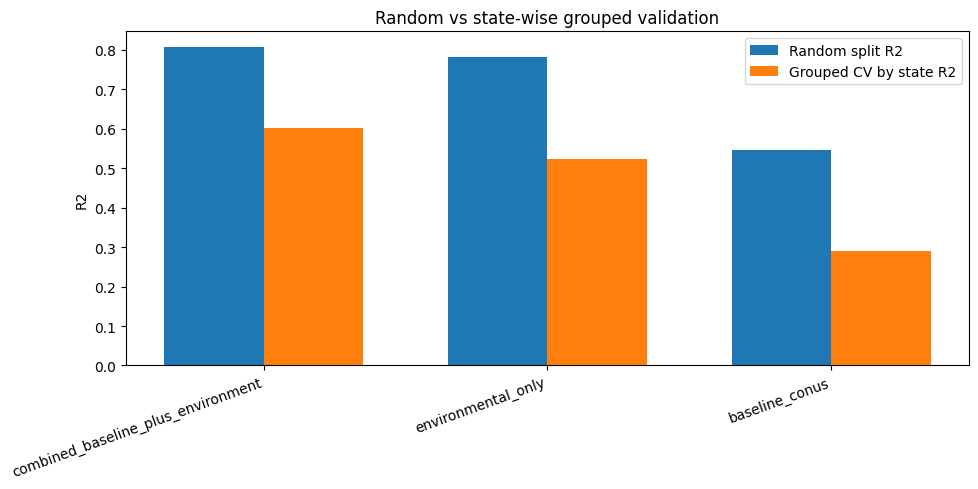

In [7]:
plot_df = results_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["random_R2"], width, label="Random split R2")
plt.bar(x + width/2, plot_df["grouped_CV_R2_mean"], width, label="Grouped CV by state R2")

plt.xticks(x, plot_df["feature_set"], rotation=20, ha="right")
plt.ylabel("R2")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Fit the best grouped-validation feature set on the full cleaned dataset
We use Random Forest and inspect feature importance.

In [8]:
best_feature_set = results_df.iloc[0]["feature_set"]
best_features = feature_sets[best_feature_set]

print("Best feature set under grouped validation:", best_feature_set)
print("Features:")
print(best_features)

best_pipe = build_pipeline(best_features, random_state=42)
best_pipe.fit(df_clean[best_features], df_clean[TARGET])

rf_model = best_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

Best feature set under grouped validation: combined_baseline_plus_environment
Features:
['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita', 'elevation_m', 'slope_deg', 'forest_frac', 'shrub_frac', 'grass_frac', 'developed_frac', 'warm_tmmx_c', 'warm_pr_mm', 'warm_wind_ms', 'warm_vpd_kpa']


,feature,importance
17,warm_pr_mm,0.240108
19,warm_vpd_kpa,0.115392
13,shrub_frac,0.110763
3,area_sq_mi,0.072870
10,elevation_m,0.067361
1,building_value,0.065119
0,population,0.062573
18,warm_wind_ms,0.043250
11,slope_deg,0.040820
14,grass_frac,0.036436


In [ ]:
# ============================================================
# Export Table 3: Feature importance of best grouped-validation model
# ============================================================

importance_export = importance_df.copy()

display(importance_export)

save_dataframe_as_pdf(
    importance_export,
    filename="table_3_best_grouped_model_feature_importance.pdf",
    rows_per_page=25,
    fontsize=8,
    fig_width=10
)

importance_export.to_csv(EXPORT_DIR / "table_3_best_grouped_model_feature_importance.csv", index=False)

In [ ]:
# ============================================================
# Export Figure 2: Feature importance for best grouped-validation model
# No plot title.
# ============================================================

top_n = min(15, len(importance_df))
plot_df = importance_df.head(top_n).sort_values("importance", ascending=True).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for i, value in enumerate(plot_df["importance"]):
    ax.text(value + 0.002, i, f"{value:.3f}", va="center", fontsize=8)

ax.set_xlim(0, plot_df["importance"].max() + 0.05)

plt.tight_layout()

fig_path_pdf = EXPORT_DIR / "figure_2_best_grouped_model_feature_importance.pdf"
fig_path_png = EXPORT_DIR / "figure_2_best_grouped_model_feature_importance.png"

plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure PDF:", fig_path_pdf)
print("Saved figure PNG:", fig_path_png)

## 8. Plot feature importance for the best grouped-validation model

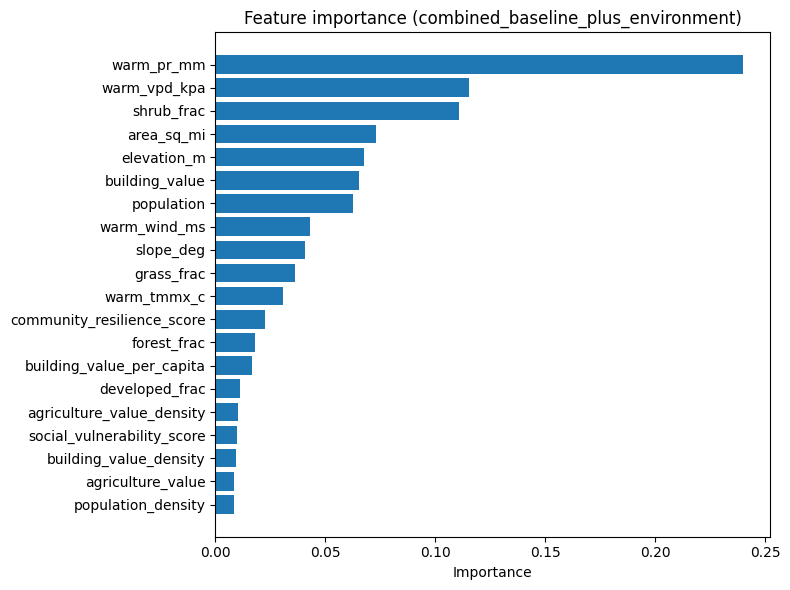

In [9]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Inspect hardest counties under the best grouped-validation feature set

In [10]:
best_group_pred = group_pred_df[group_pred_df["feature_set"] == best_feature_set].copy()
best_group_pred["abs_error"] = np.abs(best_group_pred["residual"])

print("Largest underpredictions:")
display(
    best_group_pred.sort_values("residual", ascending=False).head(20)[
        ["fold", "state", "county", "county_fips", "actual_log_wildfire_eal",
         "predicted_log_wildfire_eal", "residual", "abs_error"]
    ]
)

print("\nLargest overpredictions:")
display(
    best_group_pred.sort_values("residual", ascending=True).head(20)[
        ["fold", "state", "county", "county_fips", "actual_log_wildfire_eal",
         "predicted_log_wildfire_eal", "residual", "abs_error"]
    ]
)

Largest underpredictions:


,fold,state,county,county_fips,actual_log_wildfire_eal,predicted_log_wildfire_eal,residual,abs_error
9146,5,Minnesota,Roseau,27135,14.397116,9.422371,4.974745,4.974745
7502,2,Washington,Skamania,53059,14.996309,10.239353,4.756955,4.756955
9367,5,Nebraska,Thurston,31173,13.306423,8.575214,4.731209,4.731209
7039,2,Georgia,Chatham,13051,14.520003,10.096434,4.423568,4.423568
9138,5,Minnesota,Polk,27119,13.317344,8.972167,4.345177,4.345177
9123,5,Minnesota,Marshall,27089,13.586600,9.292217,4.294383,4.294383
8939,5,Florida,Orange,12095,16.012275,11.745305,4.266970,4.266970
9035,5,Kentucky,Magoffin,21153,12.783309,8.607676,4.175633,4.175633
6636,1,Oklahoma,Haskell,40061,14.369020,10.240923,4.128097,4.128097
6616,1,Oklahoma,Cherokee,40021,14.709894,10.590276,4.119618,4.119618



Largest overpredictions:


,fold,state,county,county_fips,actual_log_wildfire_eal,predicted_log_wildfire_eal,residual,abs_error
6468,1,Louisiana,Iberville,22047,7.356824,12.598010,-5.241186,5.241186
6491,1,Louisiana,St. James,22093,7.067927,12.209797,-5.141870,5.141870
7733,3,Illinois,Schuyler,17169,4.517911,9.613892,-5.095981,5.095981
6448,1,Louisiana,Assumption,22007,6.836385,11.910831,-5.074445,5.074445
6495,1,Louisiana,St. Mary,22101,8.284808,13.289158,-5.004350,5.004350
7679,3,Illinois,Greene,17061,4.692543,9.663569,-4.971026,4.971026
6505,1,Louisiana,West Baton Rouge,22121,7.208352,12.177300,-4.968948,4.968948
6473,1,Louisiana,Lafourche,22057,8.643557,13.596216,-4.952659,4.952659
7655,3,Illinois,Calhoun,17013,5.737363,10.659213,-4.921850,4.921850
6818,1,Texas,Kinney,48271,8.061705,12.911521,-4.849816,4.849816


In [ ]:
# ============================================================
# Export grouped-validation error analysis for the best feature set
# ============================================================

best_group_pred = group_pred_df[group_pred_df["feature_set"] == best_feature_set].copy()
best_group_pred["abs_error"] = np.abs(best_group_pred["residual"])

error_summary = pd.DataFrame({
    "Metric": [
        "Mean absolute error",
        "Median absolute error",
        "Maximum absolute error",
        "Mean residual",
        "Residual standard deviation",
        "Number of predictions"
    ],
    "Value": [
        best_group_pred["abs_error"].mean(),
        best_group_pred["abs_error"].median(),
        best_group_pred["abs_error"].max(),
        best_group_pred["residual"].mean(),
        best_group_pred["residual"].std(),
        len(best_group_pred)
    ]
})

display(error_summary)

save_dataframe_as_pdf(
    error_summary,
    filename="table_4_best_grouped_model_error_summary.pdf",
    rows_per_page=20,
    fontsize=8,
    fig_width=10
)

underpredicted = best_group_pred.sort_values("residual", ascending=False).head(20)[
    ["fold", "state", "county", "county_fips", "actual_log_wildfire_eal",
     "predicted_log_wildfire_eal", "residual", "abs_error"]
].copy()

overpredicted = best_group_pred.sort_values("residual", ascending=True).head(20)[
    ["fold", "state", "county", "county_fips", "actual_log_wildfire_eal",
     "predicted_log_wildfire_eal", "residual", "abs_error"]
].copy()

display(underpredicted)
display(overpredicted)

save_dataframe_as_pdf(
    underpredicted,
    filename="table_5_top20_underpredicted_counties_grouped_validation.pdf",
    rows_per_page=20,
    fontsize=7,
    fig_width=15
)

save_dataframe_as_pdf(
    overpredicted,
    filename="table_6_top20_overpredicted_counties_grouped_validation.pdf",
    rows_per_page=20,
    fontsize=7,
    fig_width=15
)

best_group_pred.to_csv(EXPORT_DIR / "grouped_validation_predictions_best_feature_set.csv", index=False)
underpredicted.to_csv(EXPORT_DIR / "table_5_top20_underpredicted_counties_grouped_validation.csv", index=False)
overpredicted.to_csv(EXPORT_DIR / "table_6_top20_overpredicted_counties_grouped_validation.csv", index=False)

In [ ]:
# ============================================================
# Export Figure 3: Predicted vs actual under grouped validation
# No plot title.
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(
    best_group_pred["actual_log_wildfire_eal"],
    best_group_pred["predicted_log_wildfire_eal"],
    alpha=0.55,
    s=18
)

min_val = min(
    best_group_pred["actual_log_wildfire_eal"].min(),
    best_group_pred["predicted_log_wildfire_eal"].min()
)
max_val = max(
    best_group_pred["actual_log_wildfire_eal"].max(),
    best_group_pred["predicted_log_wildfire_eal"].max()
)

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1.2)

ax.set_xlabel("Actual log wildfire EAL")
ax.set_ylabel("Predicted log wildfire EAL")
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()

fig_path_pdf = EXPORT_DIR / "figure_3_grouped_validation_predicted_vs_actual.pdf"
fig_path_png = EXPORT_DIR / "figure_3_grouped_validation_predicted_vs_actual.png"

plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure PDF:", fig_path_pdf)
print("Saved figure PNG:", fig_path_png)

In [ ]:
# ============================================================
# Export Figure 4: Residual distribution under grouped validation
# No plot title.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.hist(best_group_pred["residual"], bins=50)
ax.axvline(0, linestyle="--", linewidth=1.2)

ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("County count")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()

fig_path_pdf = EXPORT_DIR / "figure_4_grouped_validation_residual_distribution.pdf"
fig_path_png = EXPORT_DIR / "figure_4_grouped_validation_residual_distribution.png"

plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure PDF:", fig_path_pdf)
print("Saved figure PNG:", fig_path_png)

## 10. Save outputs

In [11]:
RESULTS_OUT = "/content/wildfire_risk_statewise_validation_results.csv"
GROUP_PRED_OUT = "/content/wildfire_risk_statewise_group_predictions.csv"
IMPORTANCE_OUT = "/content/wildfire_risk_statewise_combined_feature_importance.csv"

results_df.to_csv(RESULTS_OUT, index=False)
group_pred_df.to_csv(GROUP_PRED_OUT, index=False)
importance_df.to_csv(IMPORTANCE_OUT, index=False)

print("Saved:", RESULTS_OUT)
print("Saved:", GROUP_PRED_OUT)
print("Saved:", IMPORTANCE_OUT)

Saved: /content/wildfire_risk_statewise_validation_results.csv
Saved: /content/wildfire_risk_statewise_group_predictions.csv
Saved: /content/wildfire_risk_statewise_combined_feature_importance.csv


## 11. What to send back after running
Please share:
1. the `results_df` table,
2. the feature-importance table,
3. whether grouped validation stays reasonably close to the earlier random-split performance.

If grouped validation remains strong, this county-level wildfire risk setup becomes much more convincing as a thesis baseline.